# ***Ⅳ. 예측과 최적화: 대단원 마무리***

---
함수 $f(x)=x^2-kx$ 에 대하여 $\displaystyle \lim_{x\to1} f(x)=3$ 이 성립할 때, 상수 $k$의 값을 구하시오.
- 연속함수이기 때문에 극한의 값이 x = 3일때의 값과 같습니다

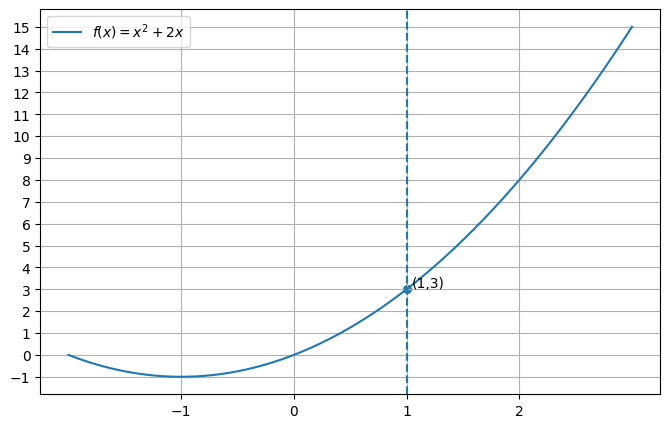

In [10]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2, 3, 400)

k = -2

# 문제에서 정의된 정의된 함수
y = x**2 - k*x

plt.figure(figsize=(8,5))
plt.plot(x, y, label=r"$f(x)=x^2+2x$")

# x=1 위치
plt.axvline(1, linestyle="--")
plt.scatter([1], [3], s=30)

plt.text(1.05, 3.1, "(1,3)")
plt.xticks(np.arange(-1, 3))
plt.yticks(np.arange(-1, 16))

plt.grid(True)
plt.legend()
plt.show()

---
이차함수
$
f(x)=3x^2+4x
$
에 대하여 $x=k$에서의 미분계수가 $2$일 때,
상수 $k$의 값을 구하시오.

- 도함수를 구하면 $f'(x)=6x+4$
- $2=6x+4$
- $x = -\frac{1}{3}$ 에서 접선의 기울기를 확인해봅니다

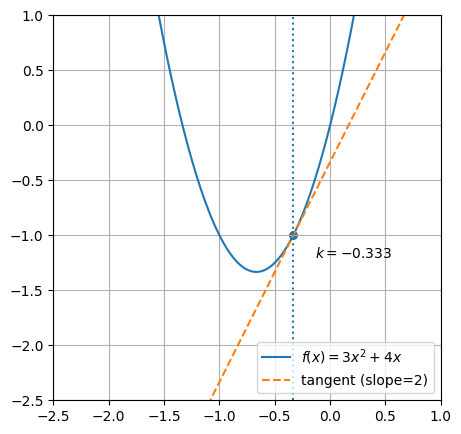

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 함수
def f(x):
    return 3*x**2 + 4*x

x = np.linspace(-3, 2, 400)
y = f(x)

# 답
k = -1/3

# 접점
x0 = k
y0 = f(x0)

# 접선의 기울기
m = 2

# 접선
tangent = m*(x - x0) + y0

plt.figure(figsize=(5,5))
plt.plot(x, y, label=r"$f(x)=3x^2+4x$")
plt.plot(x, tangent, "--",
         label="tangent (slope=2)")

plt.scatter([x0], [y0], s=30)
plt.axvline(x0, linestyle=":")
plt.text(x0+0.2, y0-0.2,fr"$k={k:.3f}$")

plt.xlim(-2.5, 1)
plt.ylim(-2.5, 1)
plt.grid(True)
plt.legend()
plt.show()

---
입력값과 실젯값이 아래 표와 같은 데이터가 있습니다

| 입력값 (x) | 실젯값 (y) | 예측값 (f(x)) | 오차  |
| ------- | ------- | ---------- | --- |
| 1       | 1.3     | 1.5        |  |
| 2       | 2.5     | 3.0        |  |
| 3       | 3.8     | 4.5        |  |

이 데이터에 대한 추세선의 식은 $f(x)=1.5x$라 할때 오차를 계산합니다

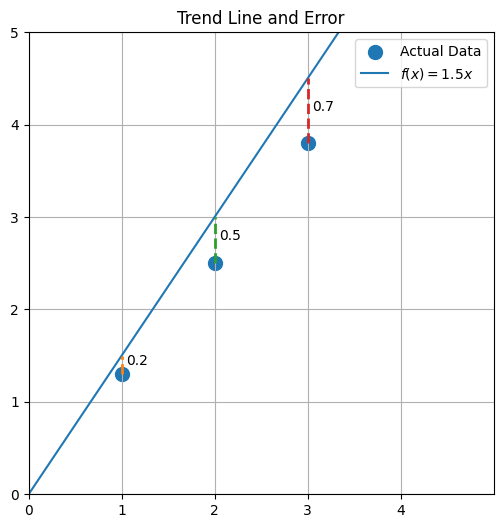

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 데이터
x = np.array([1, 2, 3])
y = np.array([1.3, 2.5, 3.8])

# 추세선
def f(x):
    return 1.5 * x

# 그래프용 x
xx = np.linspace(0, 3.5, 100)

plt.figure(figsize=(6,6))

# 실제 데이터
plt.scatter(x, y, s=100, label="Actual Data")

# 추세선
plt.plot(xx, f(xx), label=r"$f(x)=1.5x$")

# 오차 시각화
for xi, yi in zip(x, y):
    y_pred = f(xi)
    plt.plot([xi, xi], [yi, y_pred], '--', linewidth=2)
    plt.text(xi + 0.05, (yi + y_pred) / 2, f"{abs(yi-y_pred):.1f}")

plt.xticks(np.arange(0, 5, 1))
plt.yticks(np.arange(0, 6, 1))

plt.xlim(0, 5)
plt.ylim(0, 5)

plt.grid(True)
plt.legend()

plt.title("Trend Line and Error")
plt.show()

---
주어진 데이터: 
$(1,3),\ (2,3),\ (3,4),\ (4,5)$

추세선: $f(x)=ax$

예측값: $a,\ 2a,\ 3a,\ 4a$

오차 제곱: $(3-a)^2,\ (3-2a)^2,\ (4-3a)^2,\ (5-4a)^2$

$E(a)=(3-a)^2+(3-2a)^2+(4-3a)^2+(5-4a)^2$

정리하면
$E(a)=30a^2-58a+59$


## ***추세선과에 의한 예측값과 실제값간의 오차 시각화***

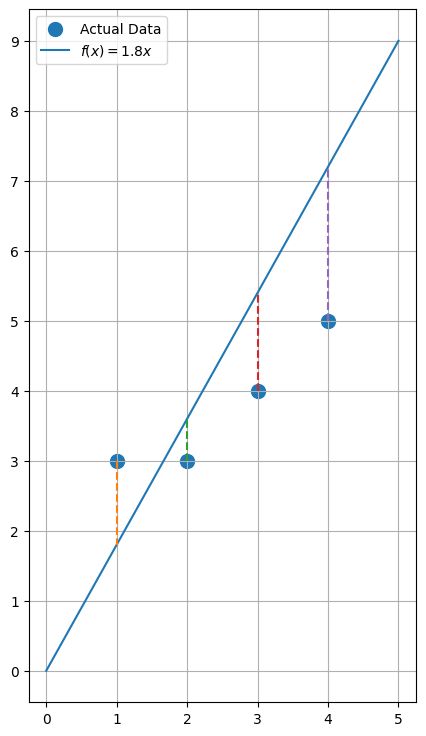

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 데이터
x = np.array([1,2,3,4])
y = np.array([3,3,4,5])

# a를 변경해봅니다
a = 1.8

xx = np.linspace(0,5,100)

plt.figure(figsize=(5,9))

plt.scatter(x, y, s=100, label="Actual Data")
plt.plot(xx, a*xx,
         label=fr"$f(x)={a}x$")

# 오차 표시
for xi, yi in zip(x, y):
    yp = a*xi
    plt.plot([xi, xi], [yi, yp],'--')

plt.xticks(np.arange(0,6,1))
plt.yticks(np.arange(0,10,1))
plt.grid(True)
plt.legend()

plt.show()

### ***손실함수 그래프***

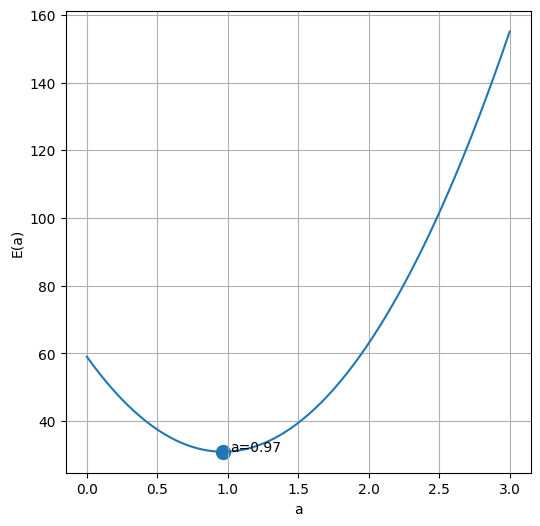

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def E(a):
    return 30*a**2 - 58*a + 59

a = np.linspace(0, 3, 400)

plt.figure(figsize=(6,6))

plt.plot(a, E(a))

# 최소점
a_min = 58/(2*30)
e_min = E(a_min)

plt.scatter([a_min], [e_min], s=100)
plt.text(a_min+0.05, e_min, fr"a={a_min:.2f}")
plt.grid(True)

plt.xlabel("a")
plt.ylabel("E(a)")

plt.show()

---
주어진 손실함수: $E(a)=7a^2-14a+12$
완전제곱식으로 정리하면 $ E(a) =7(a^2-2a)+12$

$=7\left((a-1)^2-1\right)+12$
$=7(a-1)^2+5$
따라서 $E(a)=7(a-1)^2+5$
여기서 $ (a-1)^2 \ge $
이므로 최소값은$a=1$ 에서 발생합니다

즉, 최적의 기울기는
$\boxed{a=1}$

최적화된 추세선은
$\boxed{f(x)=x}$

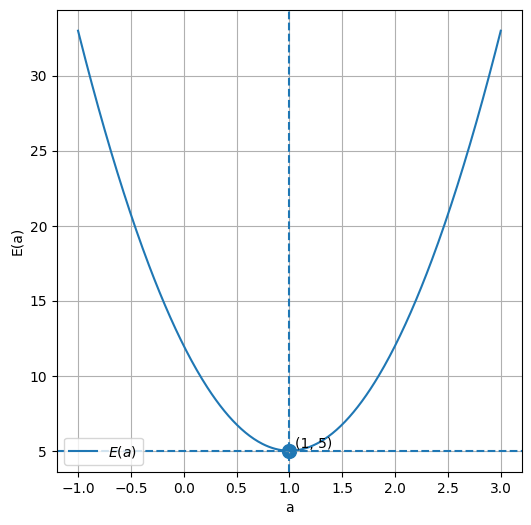

In [47]:
import numpy as np
import matplotlib.pyplot as plt

def E(a):
    return 7*a**2 - 14*a + 12

a = np.linspace(-1, 3, 400)

plt.figure(figsize=(6,6))

plt.plot(a, E(a), label=r"$E(a)$")

# 최소점
plt.scatter([1], [5], s=100)

plt.axvline(1, linestyle="--")
plt.axhline(5, linestyle="--")

plt.text(1.05, 5.2, "(1, 5)")

plt.xlabel("a")
plt.ylabel("E(a)")
plt.grid(True)
plt.legend()

plt.show()

---
손실함수:$E(a)=2a^2-12a+21$ 에 대한 문제

### ***도함수 구하기***

$E'(a)=4a-12$
최소점에서는 $E'(a)=0$ 이므로
$4a-12=0$
$a=3$

### ***최적 추세선***
추세선이 $y=ax$ 이므로 최적 추세선은 $\boxed{y=3x}$


### ***x=5에 대해 예측***

$y=3x$ 에서 $x=5$이므로 $y=15$
따라서 $\boxed{15}$

## ***손실함수 시각화***

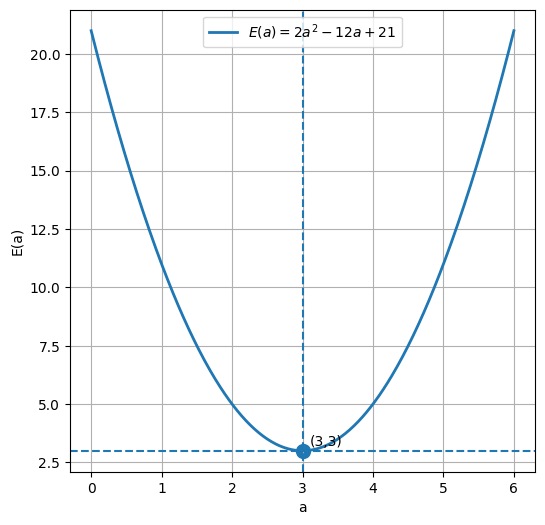

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def E(a):
    return 2*a**2 - 12*a + 21

a = np.linspace(0, 6, 400)

plt.figure(figsize=(6,6))

plt.plot(a, E(a),
         linewidth=2,
         label=r"$E(a)=2a^2-12a+21$")

# 최소 지점
a_min = 3
e_min = E(a_min)

plt.scatter([a_min], [e_min], s=100)

plt.axvline(a_min, linestyle="--")
plt.axhline(e_min, linestyle="--")

plt.text(a_min+0.1, e_min+0.2,
         fr"({a_min},{e_min})")

plt.xlabel("a")
plt.ylabel("E(a)")
plt.grid(True)
plt.legend()

plt.show()

## ***실측 데이터 예시와 추세선***
- 실측 데이터가 아래와 같으면 문제와 같은 손실함수가 나옵니다

    x |	y
    ---|---
    -1 |	-4
    0 |	1
    1 |	2

$ E(a)=(1-0a)^2+(2-a)^2+(-4+a)^2 = 2a^2-12a+21$



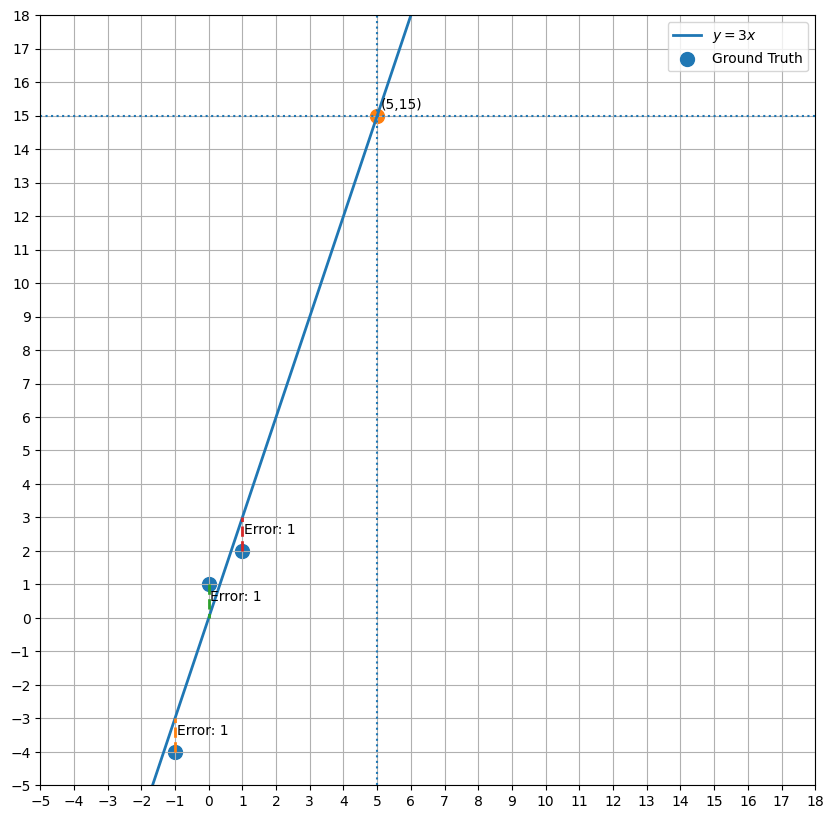

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Ground Truth
x_true = np.array([-1, 0, 1])
y_true = np.array([-4, 1, 2])

# 최적 추세선 y = 3x
x = np.linspace(-5, 6, 200)

plt.figure(figsize=(10,10))

# 추세선
plt.plot(x, 3*x,
         linewidth=2,
         label=r"$y=3x$")

# 실제 데이터
plt.scatter(x_true,y_true,s=100,label="Ground Truth")

# 오차 시각화
for xi, yi in zip(x_true, y_true):
    y_pred = 3 * xi
    plt.plot([xi, xi],[yi, y_pred],'--',linewidth=2)
    plt.text(xi + 0.05,(yi + y_pred)/2,f"Error: {abs(yi-y_pred):.0f}")

# 문제의 x=5 예측
plt.scatter([5], [15], s=100)

plt.axvline(5, linestyle=":")
plt.axhline(15, linestyle=":")

plt.text(5.1, 15.2, "(5,15)")

plt.xticks(np.arange(-5, 19, 1))
plt.yticks(np.arange(-5, 19, 1))

plt.xlim(-5, 18)
plt.ylim(-5, 18)

plt.grid(True)
plt.legend()

plt.show()

---

손실함수: $E(a)=2a^2-6a+5$

도함수: $E'(a)=4a-6$

경사하강법:

* 초깃값: $(a_0=5)$
* 학습률: $(\eta=0.1)$

### ***1번 학습***

$E'(5)=4(5)-6=14$

$a_1 = 5-0.1(14)=5-1.4=3.6$

### ***2번 학습***
$E'(3.6) = 4(3.6)-6 =8.4$

$a_2 = 3.6-0.1(8.4)=3.6-0.84=2.76$

따라서 $a$의 값을 2번 수정했을 때 $\boxed{a=2.76}$


### ***시각화***
$ 5 \rightarrow 3.6 \rightarrow 2.76 $ 으로 손실함수의 최소 지점을 향해 내려갑니다


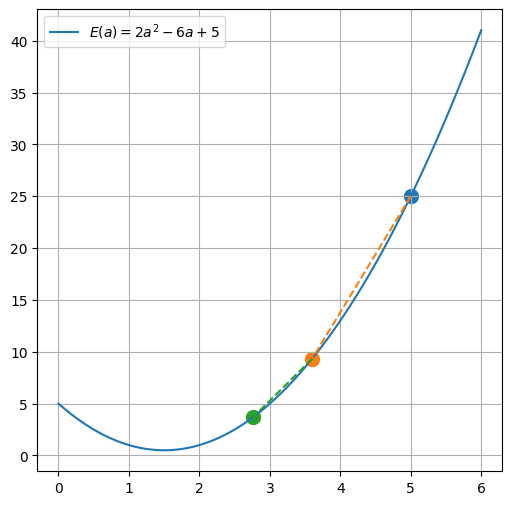

In [59]:
import numpy as np
import matplotlib.pyplot as plt

def E(a):
    return 2*a**2 - 6*a + 5

a = np.linspace(0, 6, 400)

plt.figure(figsize=(6,6))
plt.plot(a, E(a), label=r"$E(a)=2a^2-6a+5$")

# 경사하강법 이동 경로
points = [5, 3.6, 2.76]

for p in points:
    plt.scatter(p, E(p), s=100)

for i in range(len(points)-1):
    plt.plot(
        [points[i], points[i+1]],
        [E(points[i]), E(points[i+1])],
        '--'
    )

plt.grid(True)
plt.legend()
plt.show()